In [1]:
import fiftyone as fo
import fiftyone.utils.yolo as fouy
from fiftyone import ViewField as F
import fiftyone.brain as fob
import fiftyone.zoo as foz
import fiftyone.utils.yolo as fouy

In [16]:
from pathlib import Path
from tqdm import tqdm
from glob import glob
import os

from PIL import Image
import cv2
import numpy as np

import torch
from torch.utils.data import Dataset
from torchvision import transforms

In [3]:
fo.list_datasets()

['2test_video_dataset',
 'local_video_test',
 'local_video_test2',
 'local_video_test3',
 'local_video_test5',
 'local_video_test6']

In [39]:
ds_path = 'data'
dataset_dir = Path(ds_path)

In [21]:
files = os.listdir(ds_path)
imgs = [f for f in files if f.endswith(('.jpg', '.png'))]
ants = [f for f in files if f.endswith('.json')]
print(len(imgs), len(ants))

48 48


In [26]:
dataset_dir = Path(ds_path)
images = list(dataset_dir.glob("*.jpg"))
annotations = list(dataset_dir.glob("*.json"))

image_stems = {p.stem for p in images}
annotation_stems = {p.stem for p in annotations}

missing_annotations = image_stems - annotation_stems
missing_images = annotation_stems - image_stems

print(f"Missing annotations: {missing_annotations}")
print(f"Missing images: {missing_images}")

Missing annotations: set()
Missing images: set()


In [29]:
print(type(image_stems))

<class 'set'>


In [37]:
image_stems = {"c", "a", "d"}
annotation_stems = {"a", "c"}

missing_annotations = image_stems - annotation_stems
missing_images = annotation_stems - image_stems

print(f"Missing annotations: {missing_annotations}")
print(f"Missing images: {missing_images}")

Missing annotations: {'d'}
Missing images: set()


# Utils

In [4]:
def get_image_size(image_path):
    try:
        with Image.open(image_path) as img:
            width, height = img.size
            return width, height
    except Exception as e:
        print(f"Error opening image '{image_path}': {e}")
        return None, None

In [6]:
from pathlib import Path

def sanity_check_dataset(dataset_dir):
    dataset_dir = Path(dataset_dir)

    images = list(dataset_dir.glob("*.jpg"))
    annotations = list(dataset_dir.glob("*.json"))

    image_stems = {p.stem for p in images}
    annotation_stems = {p.stem for p in annotations}

    missing_annotations = image_stems - annotation_stems
    missing_images = annotation_stems - image_stems

    print(f"Total images: {len(images)}")
    print(f"Total annotations: {len(annotations)}")

    if missing_annotations:
        print(f"\n❌ Missing annotations for {len(missing_annotations)} images:")
        print(list(missing_annotations)[:10])
    else:
        print("\n✅ All images have annotations")

    if missing_images:
        print(f"\n⚠️ Annotations without images: {len(missing_images)}")
        print(list(missing_images)[:10])
    else:
        print("\n✅ All annotations have images")

    return {
        "missing_annotations": missing_annotations,
        "missing_images": missing_images,
    }

In [47]:
from collections import Counter, defaultdict

def inspect_image_annotation_dataset(
    dataset_dir,
    image_extensions=(".jpg", ".jpeg", ".png", ".webp", ".bmp"),
    annotation_extension=".json",
    check_json=True,
):
    dataset_dir = Path(dataset_dir)

    image_extensions = {ext.lower() for ext in image_extensions}
    annotation_extension = annotation_extension.lower()

    all_files = [p for p in dataset_dir.iterdir() if p.is_file()]

    images = [
        p for p in all_files
        if p.suffix.lower() in image_extensions
    ]

    annotations = [
        p for p in all_files
        if p.suffix.lower() == annotation_extension
    ]

    image_stems = {p.stem for p in images}
    annotation_stems = {p.stem for p in annotations}

    missing_annotations = sorted(image_stems - annotation_stems)
    missing_images = sorted(annotation_stems - image_stems)

    file_extension_counts = Counter(p.suffix.lower() for p in all_files)
    image_extension_counts = Counter(p.suffix.lower() for p in images)

    duplicate_stems = defaultdict(list)
    for p in all_files:
        duplicate_stems[p.stem].append(p.name)

    duplicate_stems = {
        stem: files
        for stem, files in duplicate_stems.items()
        if len(files) > 2
    }

    broken_json_files = []

    if check_json:
        for ann_path in annotations:
            try:
                with open(ann_path, "r", encoding="utf-8") as f:
                    json.load(f)
            except Exception as e:
                broken_json_files.append((ann_path.name, str(e)))

    report = {
        "num_files_total": len(all_files),
        "num_images": len(images),
        "num_annotations": len(annotations),
        "file_extension_counts": file_extension_counts,
        "image_extension_counts": image_extension_counts,
        "missing_annotations": missing_annotations,
        "missing_images": missing_images,
        "broken_json_files": broken_json_files,
        "duplicate_stems": duplicate_stems,
    }

    print("Dataset inspection")
    print("------------------")
    print(f"Total files: {report['num_files_total']}")
    print(f"Images: {report['num_images']}")
    print(f"Annotations: {report['num_annotations']}")
    print(f"File extensions: {dict(file_extension_counts)}")
    print(f"Image extensions: {dict(image_extension_counts)}")
    print(f"Missing annotations: {len(missing_annotations)}")
    print(f"Missing images: {len(missing_images)}")
    print(f"Broken JSON files: {len(broken_json_files)}")
    print(f"Duplicate/unusual stems: {len(duplicate_stems)}")

    if missing_annotations:
        print("\nExample images without annotations:")
        print(missing_annotations[:10])

    if missing_images:
        print("\nExample annotations without images:")
        print(missing_images[:10])

    if broken_json_files:
        print("\nExample broken JSON files:")
        print(broken_json_files[:5])

    return report

In [44]:
import json

def validate_annotations(dataset_dir, max_checks=50):
    dataset_dir = Path(dataset_dir)
    json_files = list(dataset_dir.glob("*.json"))[:max_checks]

    for jf in json_files:
        with open(jf, "r") as f:
            data = json.load(f)

        if "kp" not in data or "box" not in data:
            print(f"❌ Invalid format: {jf}")
            continue

        if len(data["kp"]) != 5:
            print(f"⚠️ Unexpected keypoints count in {jf}: {len(data['kp'])}")

    print("✅ Annotation validation done. No inconsistencies found in checked files.")

In [46]:
def convert_bbox_to_fiftyone(box, width, height):
    """
    Convert [x1, y1, x2, y2] pixel bbox 
    → [x, y, w, h] normalized (FiftyOne format)
    """
    x1, y1, x2, y2 = box

    return [
        x1 / width,
        y1 / height,
        (x2 - x1) / width,
        (y2 - y1) / height,
    ]

In [93]:
def convert_bbox_to_fiftyone(box, width, height):
    """
    Convert [x1, y1, x2, y2] pixel bbox 
    → [x, y, w, h] normalized (FiftyOne format)
    """
    # x1, y1, x2, y2 = box
    x2, y2, x1, y1 = box

    return [
        x1 / width,
        y1 / height,
        (x2 - x1) / width,
        (y2 - y1) / height,
    ]

In [118]:
def convert_xywh_to_fiftyone_bbox(box, width, height):
    x, y, w, h = box

    return [
        x / width,
        y / height,
        w / width,
        h / height,
    ]

In [119]:
def load_dataset_to_fiftyone(dataset: fo.Dataset, dataset_dir: str):

    image_paths = list(dataset_dir.glob("*.jpg"))
    samples = []

    for img_path in image_paths:
        json_path = img_path.with_suffix(".json")

        if not json_path.exists():
            continue

        # Load annotation
        with open(json_path, "r") as f:
            ann = json.load(f)

        # Load image to get size
        img = Image.open(img_path)
        width, height = img.size

        # --- Bounding box ---
        x1, y1, x2, y2 = ann["box"]

        # bbox = convert_bbox_to_fiftyone(ann["box"], width, height)
        bbox = convert_xywh_to_fiftyone_bbox(ann["box"], width, height)
        

        detection = fo.Detection(
            label="face",
            bounding_box=bbox,
        )

        # --- Keypoints ---
        keypoints = [
            [kp[0] / width, kp[1] / height]
            for kp in ann["kp"]
        ]

        keypoint_obj = fo.Keypoint(
            label="face_landmarks",
            points=keypoints,
        )

        # --- Sample ---
        sample = fo.Sample(filepath=str(img_path))
        sample["face"] = fo.Detections(detections=[detection])
        sample["landmarks"] = fo.Keypoints(keypoints=[keypoint_obj])

        samples.append(sample)

    dataset.add_samples(samples)

    print(f"✅ Loaded {len(samples)} samples into FiftyOne")

    return dataset

In [129]:
import numpy as np


def interocular_distance(landmarks):
    left_eye, right_eye = landmarks[0], landmarks[1]

    return float(
        np.linalg.norm(np.array(right_eye) - np.array(left_eye))
    )


def estimate_yaw(landmarks, eps=1e-6):
    left_eye, right_eye, nose = landmarks[0], landmarks[1], landmarks[2]

    iod = interocular_distance(landmarks)

    left_dist = abs(nose[0] - left_eye[0])
    right_dist = abs(right_eye[0] - nose[0])

    return float((left_dist - right_dist) / (iod + eps))


def estimate_roll_angle(landmarks):
    left_eye, right_eye = landmarks[0], landmarks[1]

    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]

    return float(np.degrees(np.arctan2(dy, dx)))


def mouth_nose_vertical_ratio(landmarks, eps=1e-6):
    nose = landmarks[2]
    left_mouth, right_mouth = landmarks[3], landmarks[4]

    mouth_center_y = (left_mouth[1] + right_mouth[1]) / 2.0
    iod = interocular_distance(landmarks)

    return float(abs(mouth_center_y - nose[1]) / (iod + eps))

In [130]:
def get_landmarks_pixels_from_sample(sample, landmarks_field="landmarks"):
    keypoints = sample[landmarks_field].keypoints

    if len(keypoints) == 0:
        return None

    points = keypoints[0].points

    width = sample.metadata.width
    height = sample.metadata.height

    landmarks_pixels = [
        [x * width, y * height]
        for x, y in points
    ]

    return landmarks_pixels

In [133]:
def attach_landmark_geometry_fields(dataset, landmarks_field="landmarks"):
    dataset.compute_metadata()

    for sample in dataset:
        landmarks = get_landmarks_pixels_from_sample(
            sample,
            landmarks_field=landmarks_field,
        )

        if landmarks is None or len(landmarks) != 5:
            sample["yaw_estimate"] = None
            sample["roll_angle"] = None
            sample["interocular_distance"] = None
            sample["mouth_nose_vertical_ratio"] = None
            sample.save()
            continue

        sample["yaw_estimate"] = estimate_yaw(landmarks)
        sample["roll_angle"] = estimate_roll_angle(landmarks)
        sample["interocular_distance"] = interocular_distance(landmarks)
        sample["mouth_nose_vertical_ratio"] = mouth_nose_vertical_ratio(landmarks)

        sample.save()

    print("Done. Geometry fields attached.")

In [136]:
def filter_face(
    landmarks,
    yaw_thresh=0.3,
    roll_thresh_deg=15,
    min_iod=20,
    max_iod=None,
    min_mouth_nose_ratio=0.3,
    max_mouth_nose_ratio=1.5,
    return_reasons=True,
):
    reasons = []

    # --- compute metrics ---
    yaw = estimate_yaw(landmarks)
    roll = estimate_roll_angle(landmarks)
    iod = interocular_distance(landmarks)
    ratio = mouth_nose_vertical_ratio(landmarks)

    # --- checks ---
    if abs(yaw) > yaw_thresh:
        reasons.append(f"yaw too large: {yaw:.3f}")

    if abs(roll) > roll_thresh_deg:
        reasons.append(f"roll too large: {roll:.2f}°")

    if iod < min_iod:
        reasons.append(f"face too small (IOD): {iod:.2f}")

    if max_iod is not None and iod > max_iod:
        reasons.append(f"face too large (IOD): {iod:.2f}")

    if ratio < min_mouth_nose_ratio or ratio > max_mouth_nose_ratio:
        reasons.append(f"invalid mouth-nose ratio: {ratio:.2f}")

    is_rejected = len(reasons) > 0

    if return_reasons:
        return is_rejected, reasons
    else:
        return is_rejected

In [139]:
def export_face_filter_results(
    dataset,
    output_json_path,
    return_reasons=True,
):
    dataset.compute_metadata()

    results = {}

    for sample in dataset:
        landmarks = get_landmarks_pixels_from_sample(sample)

        if landmarks is None or len(landmarks) != 5:
            results[sample.filepath] = (
                {"rejected": True, "reasons": ["invalid or missing landmarks"]}
                if return_reasons
                else True
            )
            continue

        result = filter_face(
            landmarks,
            return_reasons=return_reasons,
        )

        if return_reasons:
            rejected, reasons = result
            results[sample.filepath] = {
                "rejected": rejected,
                "reasons": reasons,
            }
        else:
            results[sample.filepath] = result  # just True/False

    # --- save ---
    with open(output_json_path, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)

    print(f"Saved results to {output_json_path}")

In [140]:
def attach_face_filter_result_to_fiftyone(
    dataset,
    landmarks_field="landmarks",
    output_field="rejected",
    **filter_kwargs,
):
    dataset.compute_metadata()

    for sample in dataset:
        landmarks = get_landmarks_pixels_from_sample(
            sample,
            landmarks_field=landmarks_field,
        )

        if landmarks is None or len(landmarks) != 5:
            sample[output_field] = True
            sample.save()
            continue

        rejected = filter_face(
            landmarks,
            return_reasons=False,
            **filter_kwargs,
        )

        sample[output_field] = bool(rejected)
        sample.save()

    print(f"Saved binary filter result to FiftyOne field: {output_field}")

# Load Data

In [120]:
ds_path = 'data'
dataset_dir = Path(ds_path)

In [ ]:
# fo.delete_dataset("landmarks")

In [122]:
ds_name = "landmarks"
landmarks_ds = fo.Dataset(name=ds_name, persistent=True)

In [123]:
image_paths = list(dataset_dir.glob("*.jpg"))
image_paths = list(dataset_dir.glob("*.jpg"))

In [124]:
load_dataset_to_fiftyone(landmarks_ds, dataset_dir)

 100% |███████████████████| 48/48 [220.4ms elapsed, 0s remaining, 222.5 samples/s] 
✅ Loaded 48 samples into FiftyOne


Name:        landmarks
Media type:  image
Num samples: 48
Persistent:  True
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    face:             fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    landmarks:        fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Keypoints)

In [125]:
landmarks_ds.compute_metadata()

Computing metadata...
 100% |███████████████████| 48/48 [34.7ms elapsed, 0s remaining, 1.4K samples/s] 


In [ ]:
session.close()

In [128]:
session = fo.launch_app(
    landmarks_ds,
    port=5151,
    address="127.0.0.1",
)

# Exploration

In [45]:
sanity_check_dataset(dataset_dir)
validate_annotations(dataset_dir)

Total images: 48
Total annotations: 48

✅ All images have annotations

✅ All annotations have images
✅ Annotation validation done. No inconsistencies found in checked files.


In [48]:
inspect_image_annotation_dataset(dataset_dir)

Dataset inspection
------------------
Total files: 96
Images: 48
Annotations: 48
File extensions: {'.jpg': 48, '.json': 48}
Image extensions: {'.jpg': 48}
Missing annotations: 0
Missing images: 0
Broken JSON files: 0
Duplicate/unusual stems: 0


{'num_files_total': 96,
 'num_images': 48,
 'num_annotations': 48,
 'file_extension_counts': Counter({'.jpg': 48, '.json': 48}),
 'image_extension_counts': Counter({'.jpg': 48}),
 'missing_annotations': [],
 'missing_images': [],
 'broken_json_files': [],
 'duplicate_stems': {}}

# Compute metrics and attach to samples

In [134]:
attach_landmark_geometry_fields(landmarks_ds)

Done. Geometry fields attached.


In [141]:
export_face_filter_results(landmarks_ds, "face_filter_results.json")

Saved results to face_filter_results.json


In [142]:
attach_face_filter_result_to_fiftyone(
    landmarks_ds, output_field="face_rejection_v1")

Saved binary filter result to FiftyOne field: face_rejection_v1


In [105]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image


def plot_raw_xyxy_samples(dataset_dir, n=5):
    dataset_dir = Path(dataset_dir)
    image_paths = list(dataset_dir.glob("*.jpg")) + list(dataset_dir.glob("*.jpeg")) + list(dataset_dir.glob("*.png"))

    selected = random.sample(image_paths, min(n, len(image_paths)))

    for img_path in selected:
        json_path = img_path.with_suffix(".json")

        if not json_path.exists():
            print(f"Missing annotation: {img_path.name}")
            continue

        with open(json_path, "r") as f:
            ann = json.load(f)

        img = Image.open(img_path).convert("RGB")
        x1, y1, x2, y2 = ann["box"]

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(img)

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="r",
            facecolor="none",
        )

        ax.add_patch(rect)
        ax.set_title(f"{img_path.name} | raw xyxy: {ann['box']}")
        ax.axis("off")
        plt.show()

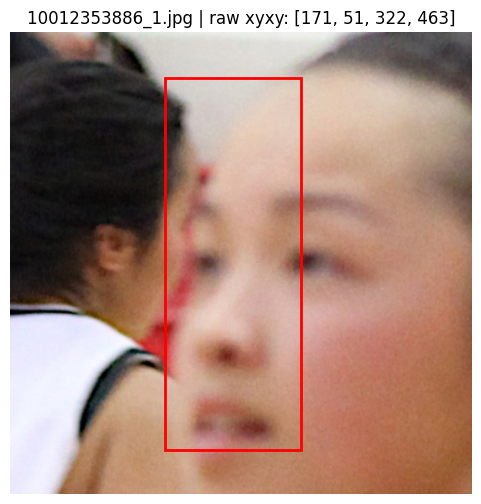

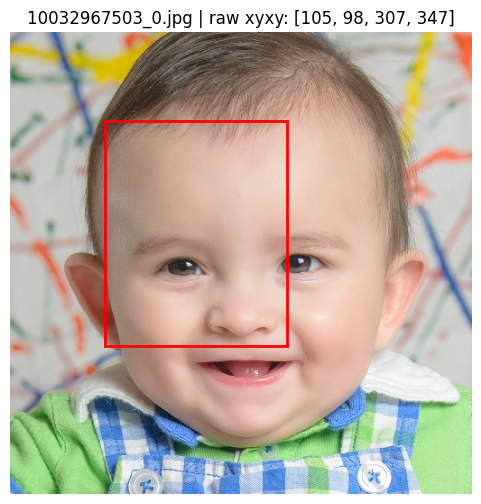

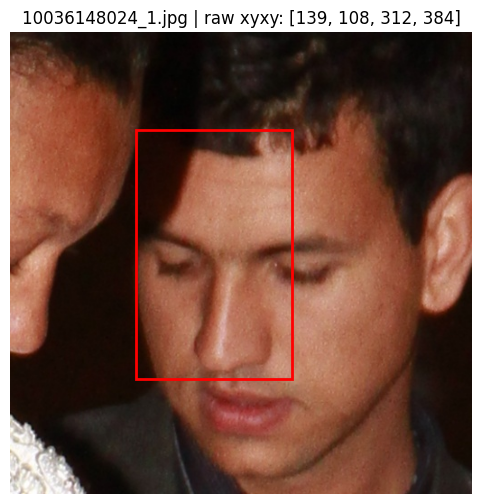

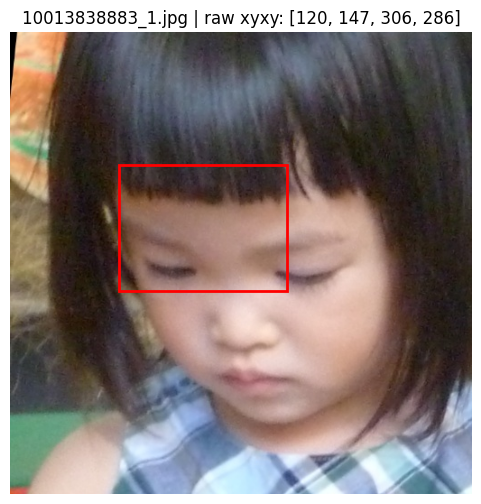

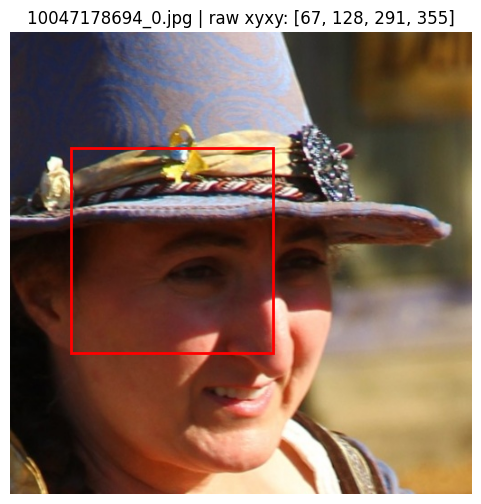

In [109]:
plot_raw_xyxy_samples(ds_path, n=5)

In [110]:
def plot_raw_xywh_samples(dataset_dir, n=5):
    dataset_dir = Path(dataset_dir)
    image_paths = (
        list(dataset_dir.glob("*.jpg")) +
        list(dataset_dir.glob("*.jpeg")) +
        list(dataset_dir.glob("*.png"))
    )

    selected = random.sample(image_paths, min(n, len(image_paths)))

    for img_path in selected:
        json_path = img_path.with_suffix(".json")

        if not json_path.exists():
            continue

        with open(json_path, "r") as f:
            ann = json.load(f)

        img = Image.open(img_path).convert("RGB")
        x, y, w, h = ann["box"]

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(img)

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="r",
            facecolor="none",
        )

        ax.add_patch(rect)
        ax.set_title(f"{img_path.name} | raw xywh: {ann['box']}")
        ax.axis("off")
        plt.show()

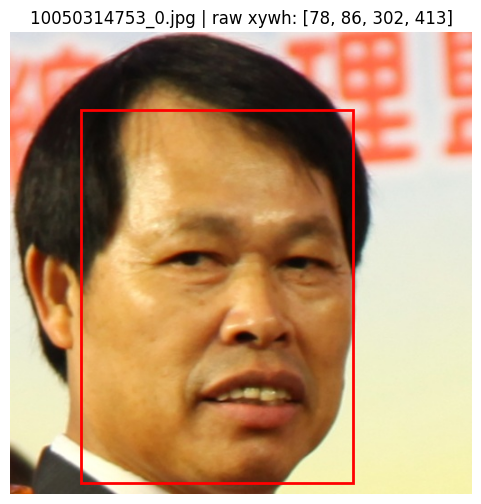

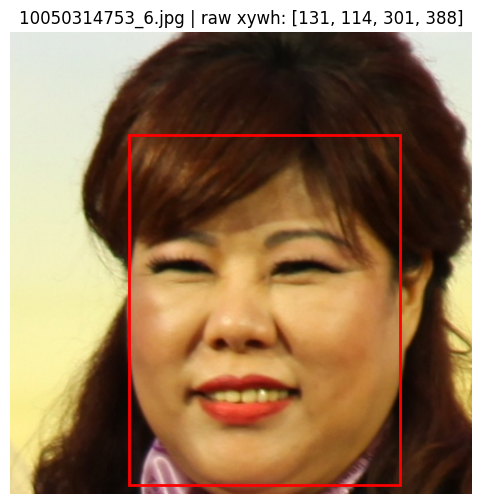

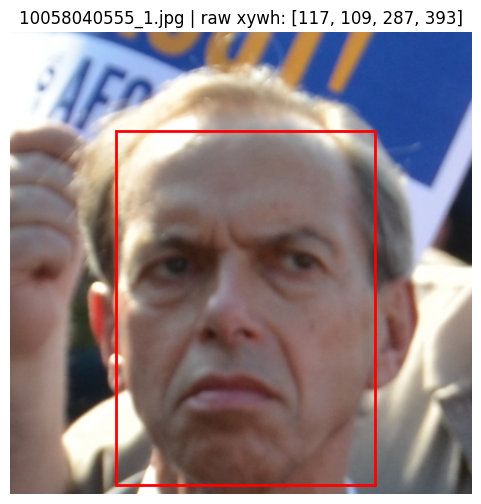

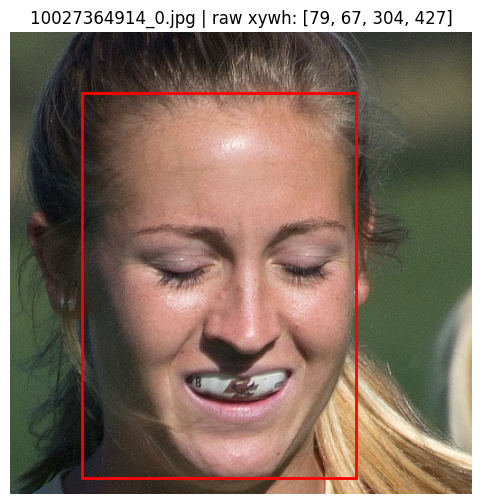

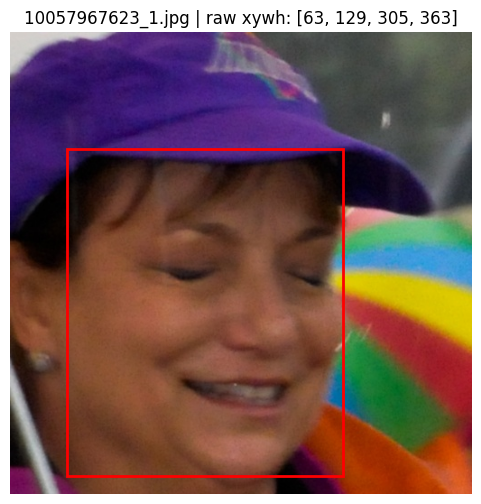

In [111]:
plot_raw_xywh_samples(ds_path, n=5)